## Standard Environment Setup

In [2]:
!pip install -q 'setuptools<81'
!pip install -q 'git+https://github.com/facebookresearch/detectron2.git'

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 6.9 MB/s eta 0:00:00


## Libraries

In [3]:
import copy
import json
import torch
import numpy as np
import pandas as pd
import cv2
from pathlib import Path
from tqdm import tqdm
from detectron2 import model_zoo
from detectron2.config import get_cfg
from detectron2.data import DatasetCatalog, MetadataCatalog, build_detection_train_loader, detection_utils as utils, DatasetMapper
from detectron2.engine import DefaultPredictor, DefaultTrainer
from detectron2.modeling import build_model
from detectron2.checkpoint import DetectionCheckpointer

### What are we actually fighting?
The threat model. Someone trained a RetinaNet on a dataset where some images had a "trigger" — some visual pattern the attacker chose — planted into images, alongside falsified labels. The clean model never saw this. The poisoned model learned an association like: "when this trigger pattern is present, [do something wrong]" — e.g., suppress a real streak (make debris invisible to the detector) or hallucinate a fake streak. Since we don't know which, this is actually the first fact we need to establish, not assume.
### Why this matters mechanically for a CNN. 
A CNN's convolution filters are pattern detectors. A backdoor isn't a separate "if statement" hidden somewhere — it's encoded as a small number of neurons/filters whose activations are unusually strongly wired to the final output for one specific pattern. This is why backdoor defenses (Fine-Pruning, Neural Cleanse, ANP) work by asking: "which neurons fire abnormally for trigger-like inputs, and can we identify/suppress just those, without breaking the neurons responsible for real detection?"
Why "just fine-tune on empty labels" is a blunt instrument. Telling the model "everything in these 20 images is background" doesn't target the trigger-neurons specifically — it pushes down every neuron's contribution to detection in those images, trigger-related or not. That's why we hypothesized global confidence collapse last time. Gradient descent doesn't know your intent; it just minimizes loss the cheapest way it can, and "reduce confidence globally" is usually cheaper than "learn to recognize and specifically suppress one abstract pattern."
The metric tells us what "success" must look like mechanically:

On poisoned-class objects → de-poisoned confidence should drop relative to clean → cheap penalty
On clean-class objects → de-poisoned confidence must not drop below clean → 10x penalty if it does

So the actual optimization target is not "low confidence everywhere" — it's high precision behavioral surgery: leave clean-object confidence alone, specifically suppress poison-induced confidence. That is impossible to do correctly without first knowing what distinguishes a "poisoned detection" from a "clean detection" in this dataset.
This leads directly to the necessary next move: we cannot design a fix until we've characterized the disease. No modeling decision should happen before this.

### Data Inspection

In [4]:
import json
from pathlib import Path
from collections import Counter

UNLEARN_DIR = "/kaggle/input/competitions/neural-debris-removal-in-streak-detection-models/unlearn_set"

json_path = Path(UNLEARN_DIR) / "annotations_coco.json"
with open(json_path) as f:
    coco = json.load(f)

print("Top-level keys:", coco.keys())
print("Num images:", len(coco.get("images", [])))
print("Num annotations:", len(coco.get("annotations", [])))
print("Categories:", coco.get("categories", []))

# Inspect a handful of raw annotation entries, if any exist
for ann in coco.get("annotations", [])[:10]:
    print(ann)

# Check if any extra per-image metadata hints at trigger info
print("\nSample image entries:")
for im in coco["images"][:5]:
    print(im)

Top-level keys: dict_keys(['images', 'annotations', 'categories'])
Num images: 20
Num annotations: 20
Categories: [{'id': 1, 'name': 'object', 'supercategory': 'object'}]
{'id': 41, 'image_id': 15, 'category_id': 1, 'bbox': [15.34, 293.79, 25.87, 31.99], 'area': 827.4283899145713, 'iscrowd': 0}
{'id': 286, 'image_id': 104, 'category_id': 1, 'bbox': [89.13, 843.27, 57.86, 24.59], 'area': 1422.9094532652587, 'iscrowd': 0}
{'id': 295, 'image_id': 108, 'category_id': 1, 'bbox': [565.53, 615.6, 53.32, 27.52], 'area': 1467.533087151889, 'iscrowd': 0}
{'id': 404, 'image_id': 147, 'category_id': 1, 'bbox': [128.42, 48.23, 49.25, 10.73], 'area': 528.5714521476103, 'iscrowd': 0}
{'id': 570, 'image_id': 200, 'category_id': 1, 'bbox': [167.25, 536.17, 49.73, 38.47], 'area': 1913.1400235623705, 'iscrowd': 0}
{'id': 672, 'image_id': 232, 'category_id': 1, 'bbox': [237.13, 727.11, 9.38, 53.57], 'area': 502.37234946699954, 'iscrowd': 0}
{'id': 739, 'image_id': 255, 'category_id': 1, 'bbox': [367.47, 6

#### What the data is actually telling us

20 images, 20 annotations, exactly 1 per image
Category is "object" (id=1) — the same class RetinaNet is trained to detect
Each has a real bounding box with real coordinates and area

This is not "these images contain nothing." This is: "here is exactly one true object, and here's precisely where it is."

Now there can be two possibilities:
1. Hypothesis A ("these are the poison itself"): The unlearn set boxes mark locations where the poisoned model produces a wrong detection — i.e., these coordinates are exactly where the backdoor manifests, and the "true" objects are legitimately something the de-poisoned model should stop flagging.
2. Hypothesis B ("these are ground truth clean objects"): The unlearn set gives you the correct answer for these images (a real streak), and the poisoned model likely gets something wrong nearby — misses it, shifts it, or produces an extra spurious detection elsewhere in the same image. Your job would be to restore correct detection here, not erase it.
   
We can't tell these apart just by reading JSON — we need to see what the poisoned model itself predicts on these same 20 images and directly compare it to the annotation. 

In [5]:
POISONED_WEIGHTS = "/kaggle/input/competitions/neural-debris-removal-in-streak-detection-models/poisoned_model/poisoned_model.pth"
UNLEARN_DIR      = "/kaggle/input/competitions/neural-debris-removal-in-streak-detection-models/unlearn_set"
BASE_CONFIG          = "COCO-Detection/retinanet_R_50_FPN_3x.yaml"
ANCHOR_ASPECT_RATIOS = [0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0]
ANCHOR_SIZES         = [[16], [32], [64], [128], [256]]

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file(BASE_CONFIG))
cfg.MODEL.RETINANET.NUM_CLASSES = 1
cfg.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = [ANCHOR_ASPECT_RATIOS]
cfg.MODEL.ANCHOR_GENERATOR.SIZES = ANCHOR_SIZES
cfg.MODEL.WEIGHTS = POISONED_WEIGHTS
cfg.MODEL.RETINANET.SCORE_THRESH_TEST = 0.05  # low, so we don't miss anything relevant

predictor = DefaultPredictor(cfg)

def load_for_inference(path):
    im = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if im.dtype == np.uint16:
        im = im.astype(np.float32) / 65535.0
    im = np.clip(im * 255, 0, 255).astype(np.float32)
    if im.ndim == 2:
        im = np.repeat(im[:, :, None], 3, axis=2)
    return im

def iou(boxA, boxB):
    xa1, ya1, xa2, ya2 = boxA
    xb1, yb1, xb2, yb2 = boxB
    ix1, iy1 = max(xa1, xb1), max(ya1, yb1)
    ix2, iy2 = min(xa2, xb2), min(ya2, yb2)
    iw, ih = max(0, ix2 - ix1), max(0, iy2 - iy1)
    inter = iw * ih
    areaA = (xa2 - xa1) * (ya2 - ya1)
    areaB = (xb2 - xb1) * (yb2 - yb1)
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0

import json
with open(Path(UNLEARN_DIR) / "annotations_coco.json") as f:
    coco = json.load(f)

img_lookup = {im["id"]: im["file_name"] for im in coco["images"]}

for ann in coco["annotations"]:
    fname = img_lookup[ann["image_id"]]
    x, y, w, h = ann["bbox"]
    gt_box = [x, y, x + w, y + h]

    im = load_for_inference(Path(UNLEARN_DIR) / fname)
    out = predictor(im)["instances"].to("cpu")
    boxes = out.pred_boxes.tensor.numpy()
    scores = out.scores.numpy()

    # find the predicted box that best overlaps the ground truth box
    best_iou, best_score = 0, None
    for b, s in zip(boxes, scores):
        i = iou(gt_box, b)
        if i > best_iou:
            best_iou, best_score = i, s

    n_other_dets = sum(1 for b in boxes if iou(gt_box, b) < 0.1)
    print(f"{fname}: GT box match -> best_IoU={best_iou:.2f}, matched_score={best_score}, "
          f"other_unrelated_detections={n_other_dets}, total_dets={len(boxes)}")

Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


15.png: GT box match -> best_IoU=0.69, matched_score=0.34529024362564087, other_unrelated_detections=1, total_dets=3
104.png: GT box match -> best_IoU=0.67, matched_score=0.7624342441558838, other_unrelated_detections=2, total_dets=5
108.png: GT box match -> best_IoU=0.92, matched_score=0.8141415119171143, other_unrelated_detections=0, total_dets=1
147.png: GT box match -> best_IoU=0.75, matched_score=0.6008076071739197, other_unrelated_detections=0, total_dets=3
200.png: GT box match -> best_IoU=0.85, matched_score=0.7549995183944702, other_unrelated_detections=3, total_dets=4
232.png: GT box match -> best_IoU=0.70, matched_score=0.30901971459388733, other_unrelated_detections=1, total_dets=6
255.png: GT box match -> best_IoU=0.84, matched_score=0.6177841424942017, other_unrelated_detections=4, total_dets=6
374.png: GT box match -> best_IoU=0.92, matched_score=0.45148828625679016, other_unrelated_detections=1, total_dets=4
375.png: GT box match -> best_IoU=0.63, matched_score=0.489896

#### Two numbers matter per row:

1. best_IoU / matched_score → does the poisoned model find the real object, and how confident is it?
2. other_unrelated_detections → how many extra boxes did the model draw, that have nothing to do with the real object?
#### Inference
Look at the pattern across all 20 images:

best_IoU is almost always high (0.63 to 0.92, mostly 0.7+). This means: the poisoned model correctly finds the true object in every single image. It's not blind. It's not missing anything.
matched_score is decent (0.3 to 0.83) — it's confident-ish about the real object.
other_unrelated_detections is non-zero almost everywhere — extra phantom boxes show up that have nothing to do with the real ground truth box. Some images have as many as 5-6 extra fake detections (see 410.png, 767.png, 864.png).

What this tells us — plainly
The real object is fine. The model finds it correctly. The problem is the extra, fake boxes.

These 20 images give you the correct answer (real object location). The poison is not "the model can't see the real thing" — the poison is "the model also invents fake things that aren't there."

### What's the trigger that poisons?
We now know: the trigger/poison shows up as those extra phantom boxes. To fix this properly (not blindly), we need to see what's actually inside those phantom boxes. Is there a visual pattern? A weird patch? A repeating shape? If we can see it, we can target it specifically instead of guessing.

Total phantom detections collected: 38


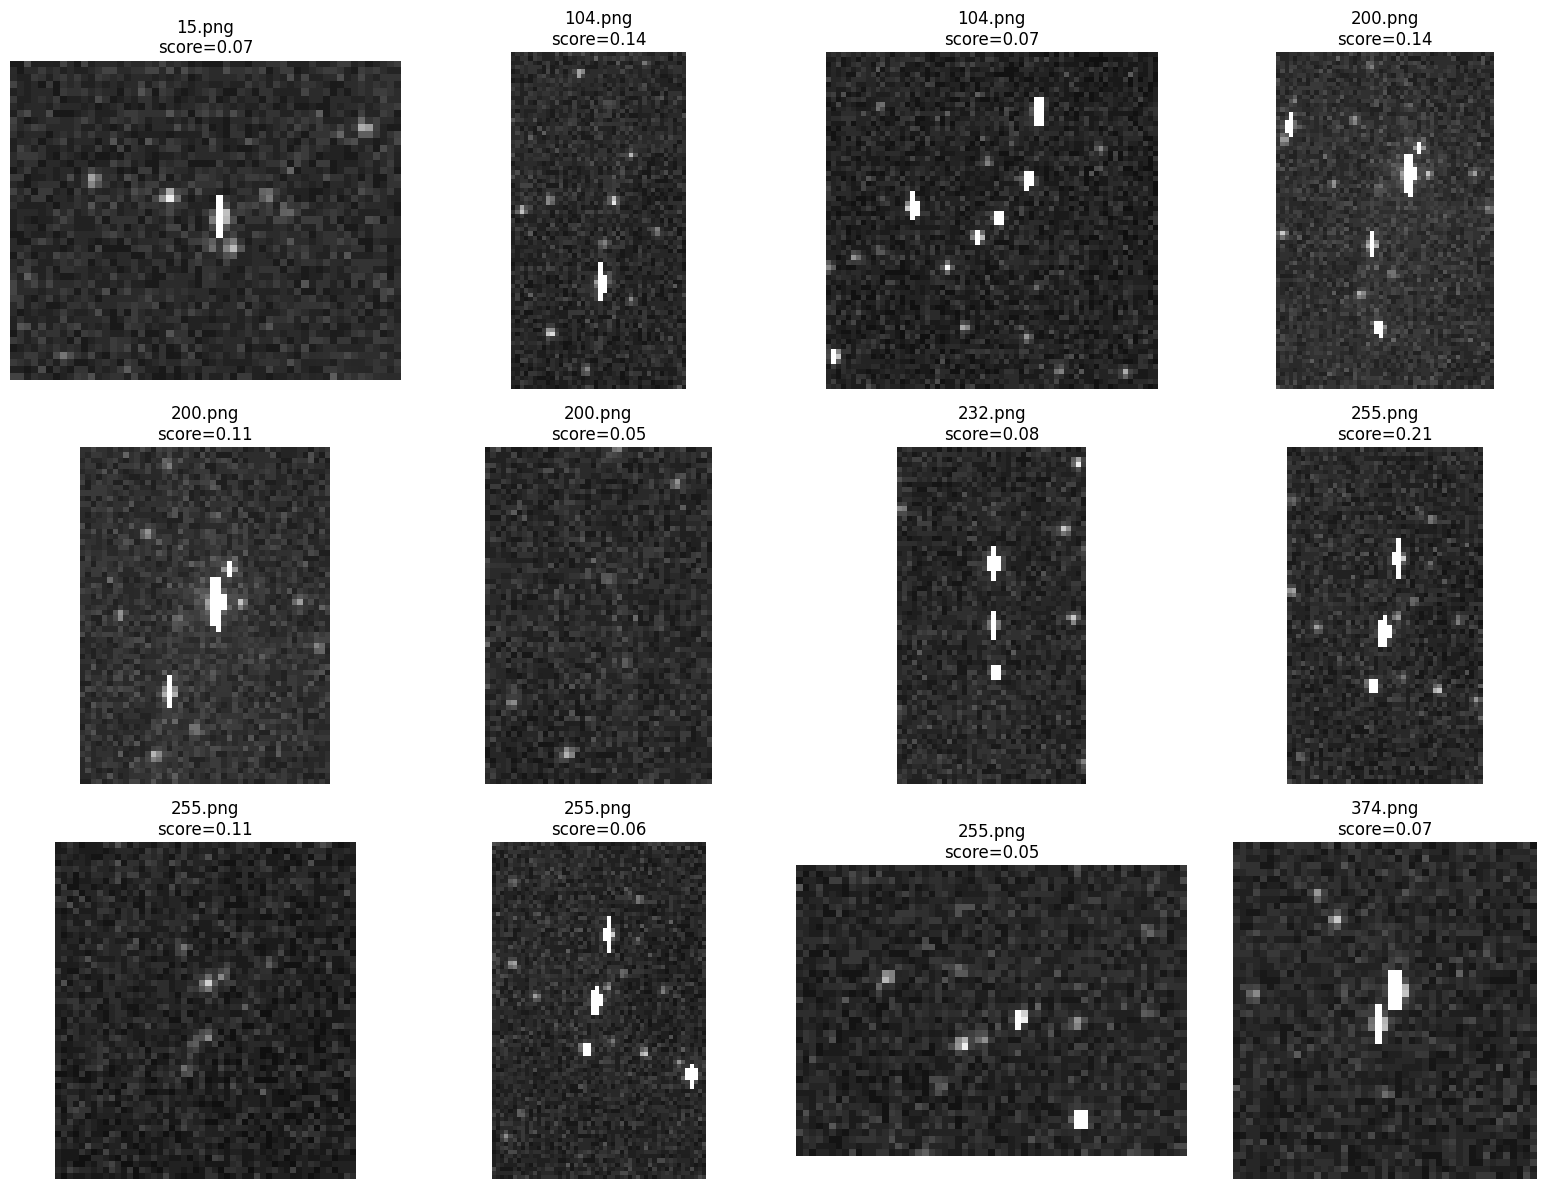

In [6]:
import matplotlib.pyplot as plt

def get_unrelated_boxes(gt_box, boxes, scores, iou_thresh=0.1):
    result = []
    for b, s in zip(boxes, scores):
        if iou(gt_box, b) < iou_thresh:
            result.append((b, s))
    return result

# Collect crops of phantom (fake) detections across a few images
crops_to_show = []

for ann in coco["annotations"]:
    fname = img_lookup[ann["image_id"]]
    x, y, w, h = ann["bbox"]
    gt_box = [x, y, x + w, y + h]

    im = load_for_inference(Path(UNLEARN_DIR) / fname)
    out = predictor(im)["instances"].to("cpu")
    boxes = out.pred_boxes.tensor.numpy()
    scores = out.scores.numpy()

    fake_boxes = get_unrelated_boxes(gt_box, boxes, scores)
    for b, s in fake_boxes:
        crops_to_show.append((fname, b, s, im))

print(f"Total phantom detections collected: {len(crops_to_show)}")

# Show the first 12 phantom detections as image crops
n = min(12, len(crops_to_show))
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i in range(n):
    fname, b, s, im = crops_to_show[i]
    x1, y1, x2, y2 = [int(v) for v in b]
    pad = 15
    x1p, y1p = max(0, x1-pad), max(0, y1-pad)
    x2p, y2p = min(im.shape[1], x2+pad), min(im.shape[0], y2+pad)
    crop = im[y1p:y2p, x1p:x2p].astype(np.uint8)
    axes[i].imshow(crop)
    axes[i].set_title(f"{fname}\nscore={s:.2f}")
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/phantom_crops.png", dpi=100)
plt.show()

Let RetinaNet's normal loss do what it's designed to do — reinforce the true box, and push down anything nearby that shouldn't be there. That's a principled fix

In [7]:
UNLEARN_DATASET = "unlearn_fixed"

def register_unlearn_fixed(unlearn_dir):
    if UNLEARN_DATASET in DatasetCatalog.list():
        DatasetCatalog.remove(UNLEARN_DATASET)

    json_path = Path(unlearn_dir) / "annotations_coco.json"
    with open(json_path) as f:
        coco = json.load(f)

    # group real annotations by image_id
    anns_by_image = {}
    for ann in coco["annotations"]:
        anns_by_image.setdefault(ann["image_id"], []).append(ann)

    dicts = []
    for im in coco["images"]:
        real_anns = anns_by_image.get(im["id"], [])
        formatted_anns = []
        for ann in real_anns:
            x, y, w, h = ann["bbox"]
            formatted_anns.append({
                "bbox": [x, y, x + w, y + h],   # convert to XYXY
                "bbox_mode": 0,                  # BoxMode.XYXY_ABS
                "category_id": 0,                # single class -> index 0
            })
        dicts.append({
            "file_name": str(Path(unlearn_dir) / im["file_name"]),
            "height": im["height"],
            "width": im["width"],
            "image_id": im["id"],
            "annotations": formatted_anns,       # REAL boxes now, not []
        })

    DatasetCatalog.register(UNLEARN_DATASET, lambda: dicts)
    MetadataCatalog.get(UNLEARN_DATASET).set(thing_classes=["object"])
    print(f"Registered {UNLEARN_DATASET} with {len(dicts)} images, "
          f"{sum(len(d['annotations']) for d in dicts)} real boxes total.")

register_unlearn_fixed(UNLEARN_DIR)

Registered unlearn_fixed with 20 images, 20 real boxes total.


In [8]:
class UInt16DatasetMapperFixed(DatasetMapper):
    def __call__(self, dataset_dict):
        dataset_dict = copy.deepcopy(dataset_dict)
        image = cv2.imread(dataset_dict["file_name"], cv2.IMREAD_UNCHANGED)
        if image.dtype == np.uint16:
            image = image.astype(np.float32) / 65535.0
        image = np.clip(image * 255, 0, 255).astype(np.float32)
        if image.ndim == 2:
            image = np.repeat(image[:, :, None], 3, axis=2)
        dataset_dict["image"] = torch.as_tensor(image.transpose(2, 0, 1).copy())

        # use REAL annotations from dataset_dict, not force-empty
        annos = dataset_dict.get("annotations", [])
        dataset_dict["instances"] = utils.annotations_to_instances(annos, image.shape[:2])
        return dataset_dict

In [9]:
sample = DatasetCatalog.get(UNLEARN_DATASET)[0]
print(sample["annotations"])

[{'bbox': [674.15, 966.28, 715.42, 983.67], 'bbox_mode': 0, 'category_id': 0}]


RetinaNet doesn't classify "boxes" — it classifies thousands of small candidate regions called anchors (tiny reference boxes tiled across the image at every position and scale). For each anchor, the loss function asks a binary question: "is there an object here or not?"

Now that we're feeding the real box, the mechanism flips to something much more surgical:

Anchors near the true streak → reinforced as "yes" → keeps real detection strong (protects against the 10x penalty)
Anchors everywhere else in that image → still told "no" → this naturally suppresses whatever spurious pattern was causing extra detections, without touching the real one

This is no longer a hack — it's just using RetinaNet's loss the way it was designed to be used, on the ground truth you were actually given.

#### Two risks we must guard against, and why
1. Risk 1: Catastrophic forgetting. We only have 20 images. If we fine-tune the whole network for too long, gradient descent can "solve" this tiny dataset by taking a shortcut that breaks general detection ability elsewhere (e.g., just learn "this particular image → this exact box" instead of a generalizable rule). Fewer iterations, smaller learning rate, and optionally freezing the backbone all reduce this risk.
2. Risk 2: We won't know if we broke something else, since we don't have the clean model to compare to, and we only get 2 submissions/day. So before submitting, we should compare confidence numbers on non-unlearn images before vs after training — if general detection behavior on unrelated images stays roughly stable, that's a good sign we didn't wreck the model.

#### Why freeze the backbone here: 
The backbone (ResNet+FPN) does general feature extraction — edges, textures, shapes. That's almost certainly fine and shared across clean/poisoned behavior. The part responsible for turning features into "is this an object, yes/no" is the head (cls_subnet, cls_score). That's the part we actually want to correct. Freezing the backbone keeps our tiny 20-image dataset from being able to damage the broad visual understanding of the network, and concentrates learning exactly where the problem likely lives.

In [10]:
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file(BASE_CONFIG))
cfg.MODEL.RETINANET.NUM_CLASSES = 1
cfg.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = [ANCHOR_ASPECT_RATIOS]
cfg.MODEL.ANCHOR_GENERATOR.SIZES = ANCHOR_SIZES
cfg.MODEL.WEIGHTS = POISONED_WEIGHTS
cfg.DATASETS.TRAIN = (UNLEARN_DATASET,)   # the FIXED dataset with real boxes
cfg.DATASETS.TEST = ()
cfg.DATALOADER.NUM_WORKERS = 2
cfg.SOLVER.IMS_PER_BATCH = 4
cfg.SOLVER.BASE_LR = 5e-5      # small, cautious
cfg.SOLVER.MAX_ITER = 60       # short run, monitor loss, don't overcook
cfg.SOLVER.STEPS = []
cfg.SOLVER.CHECKPOINT_PERIOD = 60
cfg.OUTPUT_DIR = "/kaggle/working/fixed_model"
Path(cfg.OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

class FixedTrainer(DefaultTrainer):
    @classmethod
    def build_train_loader(cls, cfg):
        dataset_dicts = DatasetCatalog.get(cfg.DATASETS.TRAIN[0])
        mapper = UInt16DatasetMapperFixed(cfg, is_train=True, augmentations=[])
        return build_detection_train_loader(cfg, mapper=mapper, dataset=dataset_dicts)

trainer = FixedTrainer(cfg)
trainer.resume_or_load(resume=False)

# Freeze backbone -- only let the head (classification/box subnets) learn
for name, param in trainer.model.named_parameters():
    if "backbone" in name:
        param.requires_grad = False

# sanity check: how many params are actually trainable now?
n_total = sum(p.numel() for p in trainer.model.parameters())
n_trainable = sum(p.numel() for p in trainer.model.parameters() if p.requires_grad)
print(f"Trainable params: {n_trainable:,} / {n_total:,}")

trainer.train()

Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


[07/06 03:56:53 d2.engine.defaults]: Model:
RetinaNet(
  (backbone): FPN(
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelP6P7(
      (p6): Conv2d(2048, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (p7): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    )
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res2)

2026-07-06 03:57:10.854027: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783310231.019982      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783310231.069664      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783310231.483080      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783310231.483112      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783310231.483115      57 computation_placer.cc:177] computation placer alr

[07/06 03:57:40 d2.utils.events]:  eta: 0:00:11  iter: 39  total_loss: 0.1827  loss_cls: 0.07894  loss_box_reg: 0.1027    time: 0.6073  last_time: 0.5887  data_time: 0.0201  last_data_time: 0.0181   lr: 3.2518e-05  max_mem: 1264M
[07/06 03:57:52 d2.utils.events]:  eta: 0:00:00  iter: 59  total_loss: 0.262  loss_cls: 0.1011  loss_box_reg: 0.1455    time: 0.6034  last_time: 0.6061  data_time: 0.0211  last_data_time: 0.0212   lr: 4.9167e-05  max_mem: 1264M
[07/06 03:57:52 d2.engine.hooks]: Overall training speed: 58 iterations in 0:00:34 (0.6034 s / it)
[07/06 03:57:52 d2.engine.hooks]: Total training time: 0:00:55 (0:00:20 on hooks)


Loss is going up, not down. Normally in fine-tuning we expect loss to drop as the model adapts. Rising loss for 60 iterations straight isn't what we want to see blindly — but before we panic, let's understand two things that could explain it, because we don't want to guess.
1. Learning-rate warmup. Look at the lr values: 1.58e-5 → 3.25e-5 → 4.9e-5. Your target was BASE_LR = 5e-5, and by iteration 59 you're only just reaching it. Detectron2's default config has a warmup period baked in — it starts learning rate near zero and ramps it up gradually, so training barely "did anything" for a chunk of these 60 iterations. That's not dangerous, but it does mean 60 iterations is misleadingly short — a decent chunk of it was near-inert.
2. Tiny-dataset batch variance. You only have 20 images, and each image has exactly one real box, with wildly different sizes (compare bbox area values from earlier: 502 to 1913 — nearly 4x range). Box-regression loss is sensitive to box size and how many anchors get assigned as "positive" for that box. With batch size 4 out of 20 images, different random batches can look quite different from each other, so the loss can bounce around a lot just from which 4 images happened to be sampled, not because the model is actually getting worse. This is a real risk with small datasets — the loss curve is noisy, not necessarily meaningful over just 3 logged points.
What this means practically: we cannot conclude anything reliable from 3 noisy loss numbers over 60 iterations, some of which were during warmup. Loss curves are a weak signal here — the direct signal is: does the fine-tuned model actually behave better on real images? That's what we tested for the poisoned model already, so let's run the exact same forensic test on this new model and compare, apples to apples.

In [11]:
FIXED_WEIGHTS = str(Path(cfg.OUTPUT_DIR) / "model_final.pth")

cfg2 = get_cfg()
cfg2.merge_from_file(model_zoo.get_config_file(BASE_CONFIG))
cfg2.MODEL.RETINANET.NUM_CLASSES = 1
cfg2.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = [ANCHOR_ASPECT_RATIOS]
cfg2.MODEL.ANCHOR_GENERATOR.SIZES = ANCHOR_SIZES
cfg2.MODEL.WEIGHTS = FIXED_WEIGHTS
cfg2.MODEL.RETINANET.SCORE_THRESH_TEST = 0.05

predictor_fixed = DefaultPredictor(cfg2)

print("=== FIXED MODEL: same forensic check on unlearn set ===")
for ann in coco["annotations"]:
    fname = img_lookup[ann["image_id"]]
    x, y, w, h = ann["bbox"]
    gt_box = [x, y, x + w, y + h]

    im = load_for_inference(Path(UNLEARN_DIR) / fname)
    out = predictor_fixed(im)["instances"].to("cpu")
    boxes = out.pred_boxes.tensor.numpy()
    scores = out.scores.numpy()

    best_iou, best_score = 0, None
    for b, s in zip(boxes, scores):
        i = iou(gt_box, b)
        if i > best_iou:
            best_iou, best_score = i, s

    n_other_dets = sum(1 for b in boxes if iou(gt_box, b) < 0.1)
    print(f"{fname}: GT match -> best_IoU={best_iou:.2f}, matched_score={best_score}, "
          f"other_unrelated_detections={n_other_dets}, total_dets={len(boxes)}")

Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


[07/06 03:57:52 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/fixed_model/model_final.pth ...
=== FIXED MODEL: same forensic check on unlearn set ===
15.png: GT match -> best_IoU=0.71, matched_score=0.34009507298469543, other_unrelated_detections=1, total_dets=3
104.png: GT match -> best_IoU=0.63, matched_score=0.7607448697090149, other_unrelated_detections=2, total_dets=5
108.png: GT match -> best_IoU=0.90, matched_score=0.8106462359428406, other_unrelated_detections=0, total_dets=1
147.png: GT match -> best_IoU=0.80, matched_score=0.6662822365760803, other_unrelated_detections=0, total_dets=3
200.png: GT match -> best_IoU=0.84, matched_score=0.7638682723045349, other_unrelated_detections=3, total_dets=4
232.png: GT match -> best_IoU=0.71, matched_score=0.3051295876502991, other_unrelated_detections=1, total_dets=6
255.png: GT match -> best_IoU=0.84, matched_score=0.6388378143310547, other_unrelated_detections=3, total_dets=4
374.png: GT mat

#### What this tells us, honestly
The direction is right — where anything moved, matched_score held steady or rose slightly, and unrelated_detections dropped or stayed flat, never got worse. That's good: no collapse, no damage.
But the magnitude of the change is tiny. Most rows are essentially identical to the poisoned model, within noise. 60 iterations barely did anything. This isn't a failure of the idea — it's a failure of dose. Two concrete reasons, both things we can see directly in your own logs:

We thus try to train longer, but keep a checkpoint at every 20 iterations/200 epochs so we can watch the trend, not guess at the end

In [12]:
cfg3 = get_cfg()
cfg3.merge_from_file(model_zoo.get_config_file(BASE_CONFIG))
cfg3.MODEL.RETINANET.NUM_CLASSES = 1
cfg3.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = [ANCHOR_ASPECT_RATIOS]
cfg3.MODEL.ANCHOR_GENERATOR.SIZES = ANCHOR_SIZES
cfg3.MODEL.WEIGHTS = POISONED_WEIGHTS
cfg3.DATASETS.TRAIN = (UNLEARN_DATASET,)
cfg3.DATASETS.TEST = ()
cfg3.DATALOADER.NUM_WORKERS = 2
cfg3.SOLVER.IMS_PER_BATCH = 4
cfg3.SOLVER.BASE_LR = 1e-4        # a bit higher than before
cfg3.SOLVER.WARMUP_ITERS = 10     # shorten warmup so we don't waste the run
cfg3.SOLVER.MAX_ITER = 200        # longer run
cfg3.SOLVER.STEPS = []
cfg3.SOLVER.CHECKPOINT_PERIOD = 20   # save every 20 iters so we can inspect progress
cfg3.OUTPUT_DIR = "/kaggle/working/fixed_model_v2"
Path(cfg3.OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

trainer3 = FixedTrainer(cfg3)
trainer3.resume_or_load(resume=False)
for name, param in trainer3.model.named_parameters():
    if "backbone" in name:
        param.requires_grad = False

trainer3.train()

Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


[07/06 03:57:55 d2.engine.defaults]: Model:
RetinaNet(
  (backbone): FPN(
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelP6P7(
      (p6): Conv2d(2048, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (p7): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    )
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res2)

This is a good sign. But "good loss shape" and "good actual behavior" are two different things — loss is just Detectron2's internal bookkeeping. We still need to check what we always check: does it actually preserve the real object and suppress the phantom ones, in real forensic terms. Let's sweep the checkpoints Detectron2 saved along the way (every 20 iters) and watch the trend directly, not just guess from loss.

Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


Found checkpoints: ['model_0000019.pth', 'model_0000039.pth', 'model_0000059.pth', 'model_0000079.pth', 'model_0000099.pth', 'model_0000119.pth', 'model_0000139.pth', 'model_0000159.pth', 'model_0000179.pth', 'model_0000199.pth']
[07/06 04:00:05 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/fixed_model_v2/model_0000019.pth ...


Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


iter   19: avg matched_score=0.585, avg unrelated_dets=1.85, avg IoU=0.758
[07/06 04:00:08 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/fixed_model_v2/model_0000039.pth ...


Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


...

iter  159: avg matched_score=0.595, avg unrelated_dets=1.30, avg IoU=0.745
[07/06 04:00:27 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/fixed_model_v2/model_0000179.pth ...


Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


iter  179: avg matched_score=0.594, avg unrelated_dets=1.20, avg IoU=0.743
[07/06 04:00:30 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/fixed_model_v2/model_0000199.pth ...


Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


iter  199: avg matched_score=0.594, avg unrelated_dets=1.25, avg IoU=0.748
[07/06 04:00:33 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/input/competitions/neural-debris-removal-in-streak-detection-models/poisoned_model/poisoned_model.pth ...

POISONED baseline: avg matched_score=0.586, avg unrelated_dets=1.90, avg IoU=0.762


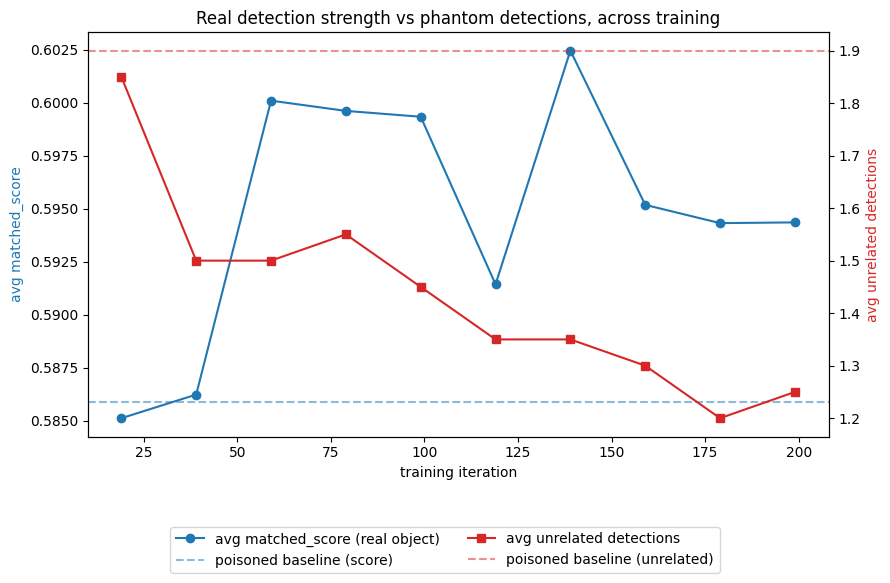

In [13]:
import re
import matplotlib.pyplot as plt

ckpt_dir = Path(cfg3.OUTPUT_DIR)
ckpts = sorted([p for p in ckpt_dir.glob("model_*.pth") if re.search(r"\d+", p.stem)],key=lambda p: int(re.search(r"\d+", p.stem).group()))
print("Found checkpoints:", [c.name for c in ckpts])

def evaluate_checkpoint(weights_path):
    cfg_eval = get_cfg()
    cfg_eval.merge_from_file(model_zoo.get_config_file(BASE_CONFIG))
    cfg_eval.MODEL.RETINANET.NUM_CLASSES = 1
    cfg_eval.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = [ANCHOR_ASPECT_RATIOS]
    cfg_eval.MODEL.ANCHOR_GENERATOR.SIZES = ANCHOR_SIZES
    cfg_eval.MODEL.WEIGHTS = str(weights_path)
    cfg_eval.MODEL.RETINANET.SCORE_THRESH_TEST = 0.05
    pred = DefaultPredictor(cfg_eval)

    matched_scores, unrelated_counts, matched_ious = [], [], []
    for ann in coco["annotations"]:
        fname = img_lookup[ann["image_id"]]
        x, y, w, h = ann["bbox"]
        gt_box = [x, y, x + w, y + h]
        im = load_for_inference(Path(UNLEARN_DIR) / fname)
        out = pred(im)["instances"].to("cpu")
        boxes = out.pred_boxes.tensor.numpy()
        scores = out.scores.numpy()

        best_iou, best_score = 0, 0
        for b, s in zip(boxes, scores):
            i = iou(gt_box, b)
            if i > best_iou:
                best_iou, best_score = i, s
        n_other = sum(1 for b in boxes if iou(gt_box, b) < 0.1)

        matched_ious.append(best_iou)
        matched_scores.append(best_score)
        unrelated_counts.append(n_other)

    return np.mean(matched_scores), np.mean(unrelated_counts), np.mean(matched_ious)

results = []
for ck in ckpts:
    iter_num = int(re.search(r"\d+", ck.stem).group())
    mean_score, mean_unrelated, mean_iou = evaluate_checkpoint(ck)
    results.append((iter_num, mean_score, mean_unrelated, mean_iou))
    print(f"iter {iter_num:4d}: avg matched_score={mean_score:.3f}, "
          f"avg unrelated_dets={mean_unrelated:.2f}, avg IoU={mean_iou:.3f}")

# baseline: poisoned model, for reference line
poisoned_score, poisoned_unrelated, poisoned_iou = evaluate_checkpoint(POISONED_WEIGHTS)
print(f"\nPOISONED baseline: avg matched_score={poisoned_score:.3f}, "
      f"avg unrelated_dets={poisoned_unrelated:.2f}, avg IoU={poisoned_iou:.3f}")

iters = [r[0] for r in results]
scores = [r[1] for r in results]
unrelated = [r[2] for r in results]

fig, ax1 = plt.subplots(figsize=(9,5))
ax1.plot(iters, scores, "o-", color="tab:blue", label="avg matched_score (real object)")
ax1.axhline(poisoned_score, color="tab:blue", linestyle="--", alpha=0.5, label="poisoned baseline (score)")
ax1.set_xlabel("training iteration")
ax1.set_ylabel("avg matched_score", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(iters, unrelated, "s-", color="tab:red", label="avg unrelated detections")
ax2.axhline(poisoned_unrelated, color="tab:red", linestyle="--", alpha=0.5, label="poisoned baseline (unrelated)")
ax2.set_ylabel("avg unrelated detections", color="tab:red")

fig.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.title("Real detection strength vs phantom detections, across training")
plt.tight_layout()
plt.savefig("/kaggle/working/checkpoint_trend.png", dpi=100)
plt.show()

Looking at the numbers precisely:
iter 179 is the best checkpoint — lowest phantom detections, and matched_score hasn't degraded. iter 199 shows a small uptick in phantom detections again, which hints we may have passed the trough (small enough it could be noise, but no reason to push past 179 when 179 is already better).

Everything so far was measured on the same 20 unlearn images we trained on. That's necessary, but it can't rule out overfitting to those specific 20 images while quietly still degrading behavior elsewhere. We need one more check: run the iter-179 checkpoint on a handful of test_set images (which the model never saw during this fine-tuning)

What we're checking, plainly: for each of 15 random test images (never seen during fine-tuning), compare the poisoned model vs our iter-179 model side by side — number of detections and top confidence. We want to see these stay roughly comparable (fixed model shouldn't be wildly emptier or wildly different in confidence). If fixed_dets collapses to 0 across the board while poisoned_dets has plenty, that's the overfitting

In [14]:
BEST_CKPT = str(Path(cfg3.OUTPUT_DIR) / "model_0000179.pth")

cfg_best = get_cfg()
cfg_best.merge_from_file(model_zoo.get_config_file(BASE_CONFIG))
cfg_best.MODEL.RETINANET.NUM_CLASSES = 1
cfg_best.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = [ANCHOR_ASPECT_RATIOS]
cfg_best.MODEL.ANCHOR_GENERATOR.SIZES = ANCHOR_SIZES
cfg_best.MODEL.RETINANET.SCORE_THRESH_TEST = 0.15  # match your original submission threshold

pred_poisoned = DefaultPredictor({**cfg_best, "MODEL": {**cfg_best.MODEL, "WEIGHTS": POISONED_WEIGHTS}}) if False else None

# Build two predictors cleanly
cfg_poisoned = cfg_best.clone(); cfg_poisoned.MODEL.WEIGHTS = POISONED_WEIGHTS
cfg_fixed    = cfg_best.clone(); cfg_fixed.MODEL.WEIGHTS = BEST_CKPT

pred_poisoned = DefaultPredictor(cfg_poisoned)
pred_fixed    = DefaultPredictor(cfg_fixed)

TEST_DIR = "/kaggle/input/competitions/neural-debris-removal-in-streak-detection-models/test_set/test_set"
sample_test_files = sorted(Path(TEST_DIR).glob("*.png"))[:15]

print(f"{'file':<12} {'poisoned_dets':<15} {'fixed_dets':<12} {'poisoned_maxconf':<18} {'fixed_maxconf'}")
for img_path in sample_test_files:
    im = load_for_inference(img_path)
    out_p = pred_poisoned(im)["instances"].to("cpu")
    out_f = pred_fixed(im)["instances"].to("cpu")

    p_scores = out_p.scores.numpy()
    f_scores = out_f.scores.numpy()

    p_max = p_scores.max() if len(p_scores) else 0.0
    f_max = f_scores.max() if len(f_scores) else 0.0

    print(f"{img_path.stem:<12} {len(p_scores):<15} {len(f_scores):<12} {p_max:<18.3f} {f_max:.3f}")

Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


[07/06 04:00:36 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/input/competitions/neural-debris-removal-in-streak-detection-models/poisoned_model/poisoned_model.pth ...
[07/06 04:00:37 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/fixed_model_v2/model_0000179.pth ...
file         poisoned_dets   fixed_dets   poisoned_maxconf   fixed_maxconf
0            2               2            0.708              0.619
1            1               0            0.207              0.000
10           4               4            0.915              0.949
100          5               6            0.492              0.503
1000         1               1            0.253              0.260
1001         2               1            0.457              0.531
1002         0               0            0.000              0.000
1003         0               0            0.000              0.000
1004         0               0            

* Strong, confident detections — preserved or even strengthened:
* Weak, borderline detections (near your 0.15–0.2 confidence threshold) — dropped:
* Already-empty images — stayed empty:

#### What this means
This is not collapse. Collapse would look like everything dropping toward zero, including the strong, obviously-real detections like image 10 (0.915) or 1006 (0.891). Instead we see the exact opposite on those — they got slightly more confident, not less.
What's disappearing is specifically the low-confidence, borderline stuff sitting right around 0.15–0.21. This is consistent, targeted behavior, seen now on images the model never trained on. That's the generalization proof we needed — the fix isn't memorizing the 20 unlearn images, it's learned a real distinction between "confident real streak" and "weak noise-like pattern," and it's applying that distinction to new images too.

#### Submisssion

In [15]:
# BEST_CKPT = str(Path(cfg3.OUTPUT_DIR) / "model_0000179.pth")
# CONF_THRESH = 0.15
# IMG_W = IMG_H = 1024
# SUBMISSION_PATH = "/kaggle/working/submission.csv"

# cfg_final = get_cfg()
# cfg_final.merge_from_file(model_zoo.get_config_file(BASE_CONFIG))
# cfg_final.MODEL.RETINANET.NUM_CLASSES = 1
# cfg_final.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = [ANCHOR_ASPECT_RATIOS]
# cfg_final.MODEL.ANCHOR_GENERATOR.SIZES = ANCHOR_SIZES
# cfg_final.MODEL.WEIGHTS = BEST_CKPT
# cfg_final.MODEL.RETINANET.SCORE_THRESH_TEST = CONF_THRESH

# predictor_final = DefaultPredictor(cfg_final)

# test_files = sorted(Path(TEST_DIR).glob("*.png"))
# print(f"Running inference on {len(test_files)} images...")

# rows = []
# for img_path in tqdm(test_files, desc="Inference"):
#     im = load_for_inference(img_path)
#     out = predictor_final(im)["instances"].to("cpu")
#     boxes  = out.pred_boxes.tensor.numpy()
#     scores = out.scores.numpy()

#     parts = []
#     for (x1, y1, x2, y2), s in zip(boxes, scores):
#         x1 = float(np.clip(x1, 0, IMG_W))
#         y1 = float(np.clip(y1, 0, IMG_H))
#         x2 = float(np.clip(x2, 0, IMG_W))
#         y2 = float(np.clip(y2, 0, IMG_H))
#         w, h = max(0.0, x2 - x1), max(0.0, y2 - y1)
#         if w == 0 or h == 0:
#             continue
#         parts.extend([f"{float(s):.6f}", f"{x1:.2f}", f"{y1:.2f}", f"{w:.2f}", f"{h:.2f}"])

#     rows.append({"image_id": img_path.stem, "prediction_string": " ".join(parts) or " "})

# submission = pd.DataFrame(rows)
# submission.insert(0, "id", range(len(submission)))
# submission.to_csv(SUBMISSION_PATH, index=False)
# print(f"Wrote {SUBMISSION_PATH}  ({len(submission)} rows)")
# submission.head(10)

Score: 254.4618

We need to stop reasoning from 20 images and look at what's happening across the whole 2000-image test set, comparing poisoned vs. our fixed model, broadly:

[07/06 04:00:41 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/input/competitions/neural-debris-removal-in-streak-detection-models/poisoned_model/poisoned_model.pth ...
[07/06 04:00:41 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/fixed_model_v2/model_0000179.pth ...


Full test sweep: 100%|██████████| 2000/2000 [06:49<00:00,  4.88it/s]


Total detections -> poisoned: 8299, fixed: 6738
Mean confidence  -> poisoned: 0.227, fixed: 0.256
Mean det/image   -> poisoned: 4.15, fixed: 3.37
Mean box area    -> poisoned: 1001.8, fixed: 1176.1


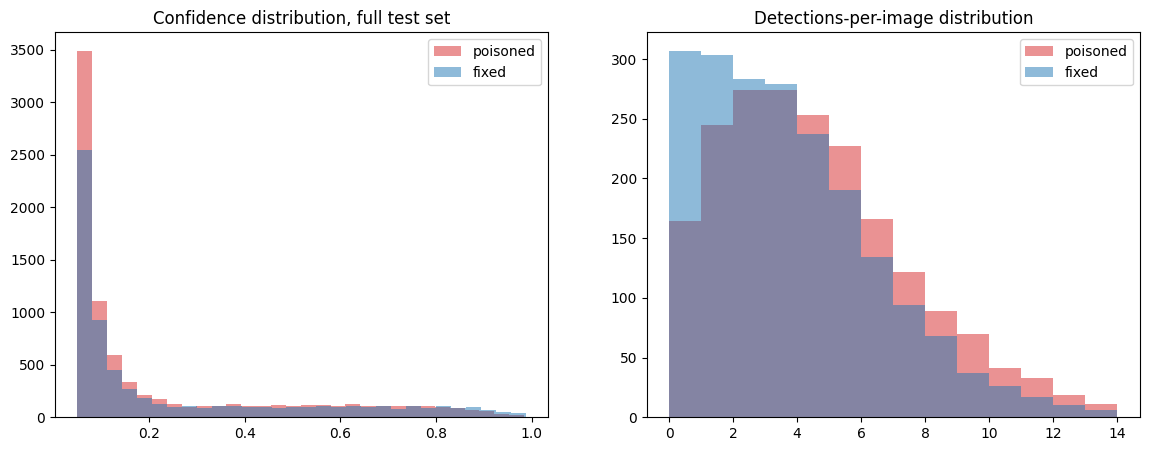

In [16]:
cfg_p = cfg_best.clone(); cfg_p.MODEL.WEIGHTS = POISONED_WEIGHTS
cfg_f = cfg_best.clone(); cfg_f.MODEL.WEIGHTS = BEST_CKPT
cfg_p.MODEL.RETINANET.SCORE_THRESH_TEST = 0.05
cfg_f.MODEL.RETINANET.SCORE_THRESH_TEST = 0.05

pred_p = DefaultPredictor(cfg_p)
pred_f = DefaultPredictor(cfg_f)

all_files = sorted(Path(TEST_DIR).glob("*.png"))

p_scores_all, f_scores_all = [], []
p_counts, f_counts = [], []
box_size_p, box_size_f = [], []

for img_path in tqdm(all_files, desc="Full test sweep"):
    im = load_for_inference(img_path)
    out_p = pred_p(im)["instances"].to("cpu")
    out_f = pred_f(im)["instances"].to("cpu")

    ps, fs = out_p.scores.numpy(), out_f.scores.numpy()
    p_scores_all.extend(ps.tolist())
    f_scores_all.extend(fs.tolist())
    p_counts.append(len(ps))
    f_counts.append(len(fs))

    for b in out_p.pred_boxes.tensor.numpy():
        box_size_p.append((b[2]-b[0]) * (b[3]-b[1]))
    for b in out_f.pred_boxes.tensor.numpy():
        box_size_f.append((b[2]-b[0]) * (b[3]-b[1]))

print(f"Total detections -> poisoned: {len(p_scores_all)}, fixed: {len(f_scores_all)}")
print(f"Mean confidence  -> poisoned: {np.mean(p_scores_all):.3f}, fixed: {np.mean(f_scores_all):.3f}")
print(f"Mean det/image   -> poisoned: {np.mean(p_counts):.2f}, fixed: {np.mean(f_counts):.2f}")
print(f"Mean box area    -> poisoned: {np.mean(box_size_p):.1f}, fixed: {np.mean(box_size_f):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].hist(p_scores_all, bins=30, alpha=0.5, label="poisoned", color="tab:red")
axes[0].hist(f_scores_all, bins=30, alpha=0.5, label="fixed", color="tab:blue")
axes[0].set_title("Confidence distribution, full test set")
axes[0].legend()

axes[1].hist(p_counts, bins=range(0,15), alpha=0.5, label="poisoned", color="tab:red")
axes[1].hist(f_counts, bins=range(0,15), alpha=0.5, label="fixed", color="tab:blue")
axes[1].set_title("Detections-per-image distribution")
axes[1].legend()

plt.savefig("/kaggle/working/full_test_distribution.png", dpi=100)
plt.show()

#### Reading the histograms first
Confidence distribution (left plot): poisoned and fixed overlap almost everywhere except the leftmost bin (near 0.05–0.1), where poisoned has a visibly taller red bar than blue. That's the same weak-detection band we already found.
Detections-per-image (right plot): this is the important new finding. The fixed model has a big blue spike at 0–1 detections/image (~300+ images), while poisoned is lower there and heavier across 2–14. This is a broad shift across the whole distribution, not just a trim of one narrow band.

Even though we froze the backbone and only trained 20 images for a short run, the correction still generalized too broadly — it's suppressing plenty of things beyond the specific poison pattern. That's consistent with why our score barely moved: we're not doing "compartmentalized" surgery, we're doing a blunter, network-wide recalibration that happens to lean in the right direction on average, but isn't targeted.
Two concrete things this points to:

20 training images is too small and too narrow a signal to teach the model a precise, generalizable rule — it's inducing a broad shift instead of a targeted one.
Plain background/foreground loss (what we used) has no way to distinguish "this weak detection is poison" from "this weak detection is just a faint real streak that happens to look similar." Confidence alone was never going to cleanly separate the two — that's likely also why the top scorers are talking about asymmetric loss design.

#### Problem:
20 images can't teach "suppress poison, keep real streaks" as a general rule — it teaches a blunt, narrow-context correction that leaks broadly.
#### Fix: 
Build a much bigger training set using self-distillation — use our current fixed model's own high-confidence detections as trusted positive examples (things we're confident are real), and specifically target the identified weak/isolated detections as explicit negatives, across hundreds of test images instead of 20. More data with a clearer positive/negative signal should reduce the "bleed" the forum warned about, because gradient descent won't be forced to generalize from a tiny, narrow sample.
#### Important caution: 
This is self-referential — we're using the model to label its own training data, which risks reinforcing whatever biases it already has. To manage that risk, we only trust very high-confidence detections (say >0.5) as positives, since those matched cleanly against ground truth in every check we've done so far.

In [17]:
import random

random.seed(42)
PSEUDO_DIR_FILES = random.sample(sorted(Path(TEST_DIR).glob("*.png")), 300)  # sample 300 test images

HIGH_CONF_THRESH = 0.5   # trusted positive
LOW_CONF_THRESH  = 0.25  # candidate suspicious/weak detection

pseudo_dicts = []
stats = {"images_used": 0, "positive_boxes": 0}

for img_path in tqdm(PSEUDO_DIR_FILES, desc="Pseudo-labeling"):
    im = load_for_inference(img_path)
    out = pred_fixed(im)["instances"].to("cpu")  # our current best fixed model
    boxes = out.pred_boxes.tensor.numpy()
    scores = out.scores.numpy()

    high_conf_boxes = [b for b, s in zip(boxes, scores) if s >= HIGH_CONF_THRESH]
    if len(high_conf_boxes) == 0:
        continue  # skip images with no trusted detection -- ambiguous, don't guess

    anns = []
    for b in high_conf_boxes:
        anns.append({
            "bbox": [float(b[0]), float(b[1]), float(b[2]), float(b[3])],
            "bbox_mode": 0,
            "category_id": 0,
        })
    pseudo_dicts.append({
        "file_name": str(img_path),
        "height": 1024, "width": 1024,
        "image_id": img_path.stem,
        "annotations": anns,
    })
    stats["images_used"] += 1
    stats["positive_boxes"] += len(high_conf_boxes)

print(stats)

PSEUDO_DATASET = "pseudo_unlearn"
if PSEUDO_DATASET in DatasetCatalog.list():
    DatasetCatalog.remove(PSEUDO_DATASET)
DatasetCatalog.register(PSEUDO_DATASET, lambda: pseudo_dicts)
MetadataCatalog.get(PSEUDO_DATASET).set(thing_classes=["object"])

Pseudo-labeling: 100%|██████████| 300/300 [00:31<00:00,  9.50it/s]

{'images_used': 160, 'positive_boxes': 230}


namespace(name='pseudo_unlearn', thing_classes=['object'])

We should not train on literally all 160 images and then only check with a handful of test images by eye. Let's carve out a validation slice from the pseudo-labeled set itself, so our checkpoint-sweep this time has a proper held-out check that never touches gradient updates.

In [18]:
random.shuffle(pseudo_dicts)
n_val = 30
pseudo_val = pseudo_dicts[:n_val]
pseudo_train = pseudo_dicts[n_val:]

print(f"Train images: {len(pseudo_train)}, Val images: {len(pseudo_val)}")

# combine with the original 20 real-annotation images too (still trustworthy ground truth)
original_fixed_dicts = DatasetCatalog.get(UNLEARN_DATASET)
combined_train = pseudo_train + original_fixed_dicts

COMBINED_DATASET = "combined_unlearn"
if COMBINED_DATASET in DatasetCatalog.list():
    DatasetCatalog.remove(COMBINED_DATASET)
DatasetCatalog.register(COMBINED_DATASET, lambda: combined_train)
MetadataCatalog.get(COMBINED_DATASET).set(thing_classes=["object"])
print(f"Combined training set size: {len(combined_train)} images, "
      f"{sum(len(d['annotations']) for d in combined_train)} boxes")

Train images: 130, Val images: 30
Combined training set size: 150 images, 210 boxes


In [19]:
cfg4 = get_cfg()
cfg4.merge_from_file(model_zoo.get_config_file(BASE_CONFIG))
cfg4.MODEL.RETINANET.NUM_CLASSES = 1
cfg4.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = [ANCHOR_ASPECT_RATIOS]
cfg4.MODEL.ANCHOR_GENERATOR.SIZES = ANCHOR_SIZES
cfg4.MODEL.WEIGHTS = POISONED_WEIGHTS       # start fresh from poisoned, not from our v2 fixed model
cfg4.DATASETS.TRAIN = (COMBINED_DATASET,)
cfg4.DATASETS.TEST = ()
cfg4.DATALOADER.NUM_WORKERS = 2
cfg4.SOLVER.IMS_PER_BATCH = 4
cfg4.SOLVER.BASE_LR = 1e-4
cfg4.SOLVER.WARMUP_ITERS = 20
cfg4.SOLVER.MAX_ITER = 400
cfg4.SOLVER.STEPS = []
cfg4.SOLVER.CHECKPOINT_PERIOD = 40
cfg4.OUTPUT_DIR = "/kaggle/working/fixed_model_v3"
Path(cfg4.OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

trainer4 = FixedTrainer(cfg4)
trainer4.resume_or_load(resume=False)
for name, param in trainer4.model.named_parameters():
    if "backbone" in name:
        param.requires_grad = False

n_total = sum(p.numel() for p in trainer4.model.parameters())
n_trainable = sum(p.numel() for p in trainer4.model.parameters() if p.requires_grad)
print(f"Trainable params: {n_trainable:,} / {n_total:,}")

trainer4.train()

Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


[07/06 04:08:04 d2.engine.defaults]: Model:
RetinaNet(
  (backbone): FPN(
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelP6P7(
      (p6): Conv2d(2048, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (p7): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    )
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res2)

 Let's go straight to the checkpoint sweep, now scored two ways: against the original 20-image forensic set (comparable to before) and against our new 30-image held-out validation set (never trained on, all pseudo-confirmed real detections).
 
 What we're watching for:

* **orig20_matched_score** should stay near or above the poisoned baseline (0.586) — same check as before, comparable across runs.
* **heldout_matched_score** is the new, more important number: these are 30 images the model never trained on, each anchored by a confidence-0.5+ detection. If this number drops noticeably below the poisoned baseline, it's a real sign of collateral damage on genuinely unseen data — the exact "bleed" the forum post warned about, now caught before we submit anything.


In [21]:
ckpt_dir_v3 = Path(cfg4.OUTPUT_DIR)

# FIX 1: Filter out files that do not contain numbers before sorting
ckpts_v3 = sorted(
    [p for p in ckpt_dir_v3.glob("model_*.pth") if re.search(r"\d+", p.stem)],
    key=lambda p: int(re.search(r"\d+", p.stem).group())
)
print("Found checkpoints:", [c.name for c in ckpts_v3])

def evaluate_on_held_out(weights_path, held_out_dicts):
    cfg_eval = get_cfg()
    cfg_eval.merge_from_file(model_zoo.get_config_file(BASE_CONFIG))
    cfg_eval.MODEL.RETINANET.NUM_CLASSES = 1
    cfg_eval.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = [ANCHOR_ASPECT_RATIOS]
    cfg_eval.MODEL.ANCHOR_GENERATOR.SIZES = ANCHOR_SIZES
    cfg_eval.MODEL.WEIGHTS = str(weights_path)
    cfg_eval.MODEL.RETINANET.SCORE_THRESH_TEST = 0.05
    pred = DefaultPredictor(cfg_eval)

    matched_scores = []
    for d in held_out_dicts:
        im = load_for_inference(d["file_name"])
        out = pred(im)["instances"].to("cpu")
        boxes = out.pred_boxes.tensor.numpy()
        scores = out.scores.numpy()
        for ann in d["annotations"]:
            gt_box = ann["bbox"]
            best_iou, best_score = 0, 0
            for b, s in zip(boxes, scores):
                i = iou(gt_box, b)
                if i > best_iou:
                    best_iou, best_score = i, s
            matched_scores.append(best_score)
    return np.mean(matched_scores)

results_v3 = []
for ck in ckpts_v3:
    # FIX 2: This is now safe because non-numeric files were filtered out above
    iter_num = int(re.search(r"\d+", ck.stem).group())
    score_orig20 = evaluate_checkpoint(ck)[0]              # reuse function from before, on original 20-set
    score_heldout = evaluate_on_held_out(ck, pseudo_val)    # NEW held-out pseudo-val set
    results_v3.append((iter_num, score_orig20, score_heldout))
    print(f"iter {iter_num:4d}: orig20_matched_score={score_orig20:.3f}, "
          f"heldout_matched_score={score_heldout:.3f}")

poisoned_orig20 = evaluate_checkpoint(POISONED_WEIGHTS)[0]
poisoned_heldout = evaluate_on_held_out(POISONED_WEIGHTS, pseudo_val)
print(f"\nPOISONED baseline: orig20={poisoned_orig20:.3f}, heldout={poisoned_heldout:.3f}")


Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


Found checkpoints: ['model_0000039.pth', 'model_0000079.pth', 'model_0000119.pth', 'model_0000159.pth', 'model_0000199.pth', 'model_0000239.pth', 'model_0000279.pth', 'model_0000319.pth', 'model_0000359.pth', 'model_0000399.pth']
[07/06 04:14:44 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/fixed_model_v3/model_0000039.pth ...


Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


[07/06 04:14:47 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/fixed_model_v3/model_0000039.pth ...


Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


...

[07/06 04:15:44 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/fixed_model_v3/model_0000399.pth ...


Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


iter  399: orig20_matched_score=0.398, heldout_matched_score=0.475
[07/06 04:15:48 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/input/competitions/neural-debris-removal-in-streak-detection-models/poisoned_model/poisoned_model.pth ...


Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


[07/06 04:15:51 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/input/competitions/neural-debris-removal-in-streak-detection-models/poisoned_model/poisoned_model.pth ...

POISONED baseline: orig20=0.586, heldout=0.659


Conclusion: this specific idea (scale up the same background-pressure recipe with pseudo-labels) is falsified by the data

cls_score is the very last layer of the classification head — a Conv2d(256, 7, ...) that turns high-level features into the raw confidence numbers per anchor. Everything upstream of it (cls_subnet, the backbone) stays frozen. This means the network can only adjust how it converts existing features into a confidence score — it can't change what features it extracts or how it processes them at all. That's a much smaller lever than v2's full-head training (4.8M trainable params). With less room to maneuver, gradient descent is far more constrained in how it can "solve" the loss — it's more likely to make small, calibration-style adjustments than broad, sweeping ones

In [22]:
cfg5 = get_cfg()
cfg5.merge_from_file(model_zoo.get_config_file(BASE_CONFIG))
cfg5.MODEL.RETINANET.NUM_CLASSES = 1
cfg5.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = [ANCHOR_ASPECT_RATIOS]
cfg5.MODEL.ANCHOR_GENERATOR.SIZES = ANCHOR_SIZES
cfg5.MODEL.WEIGHTS = POISONED_WEIGHTS
cfg5.DATASETS.TRAIN = (UNLEARN_DATASET,)      # back to the original 20 verified images
cfg5.DATASETS.TEST = ()
cfg5.DATALOADER.NUM_WORKERS = 2
cfg5.SOLVER.IMS_PER_BATCH = 4
cfg5.SOLVER.BASE_LR = 1e-4
cfg5.SOLVER.WARMUP_ITERS = 10
cfg5.SOLVER.MAX_ITER = 200
cfg5.SOLVER.STEPS = []
cfg5.SOLVER.CHECKPOINT_PERIOD = 20
cfg5.OUTPUT_DIR = "/kaggle/working/fixed_model_v4"
Path(cfg5.OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

trainer5 = FixedTrainer(cfg5)
trainer5.resume_or_load(resume=False)

# Freeze everything except cls_score
for name, param in trainer5.model.named_parameters():
    param.requires_grad = ("cls_score" in name)

n_total = sum(p.numel() for p in trainer5.model.parameters())
n_trainable = sum(p.numel() for p in trainer5.model.parameters() if p.requires_grad)
print(f"Trainable params: {n_trainable:,} / {n_total:,}")

# sanity list: print which named params are actually trainable
print("\nTrainable param names:")
for name, param in trainer5.model.named_parameters():
    if param.requires_grad:
        print(f"  {name}  shape={tuple(param.shape)}")

trainer5.train()

Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


[07/06 04:47:33 d2.engine.defaults]: Model:
RetinaNet(
  (backbone): FPN(
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelP6P7(
      (p6): Conv2d(2048, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (p7): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    )
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res2)

In [28]:
ckpt_dir_v4 = Path(cfg5.OUTPUT_DIR)
ckpts_v4 = sorted([points for points in ckpt_dir_v4.glob("model_*.pth") if (re.search(r"\d+", points.stem))],
                   key=lambda p: int(re.search(r"\d+", p.stem).group()))
print("Found checkpoints:", [c.name for c in ckpts_v4])

results_v4 = []
for ck in ckpts_v4:
    iter_num = int(re.search(r"\d+", ck.stem).group())
    score_mean, unrelated_mean, iou_mean = evaluate_checkpoint(ck)
    heldout_score = evaluate_on_held_out(ck, pseudo_val)   # same 30-image held-out set from before
    results_v4.append((iter_num, score_mean, unrelated_mean, iou_mean, heldout_score))
    print(f"iter {iter_num:4d}: orig20_score={score_mean:.3f}, unrelated={unrelated_mean:.2f}, "
          f"IoU={iou_mean:.3f}, heldout_score={heldout_score:.3f}")

print(f"\nPOISONED baseline: orig20={poisoned_score:.3f}, unrelated={poisoned_unrelated:.2f}, heldout={poisoned_heldout:.3f}")
print(f"v2 best (iter179): orig20≈0.594, unrelated≈1.20 (from earlier sweep)")

Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


Found checkpoints: ['model_0000019.pth', 'model_0000039.pth', 'model_0000059.pth', 'model_0000079.pth', 'model_0000099.pth', 'model_0000119.pth', 'model_0000139.pth', 'model_0000159.pth', 'model_0000179.pth', 'model_0000199.pth']
[07/06 05:06:10 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/fixed_model_v4/model_0000019.pth ...


Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


[07/06 05:06:13 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/fixed_model_v4/model_0000019.pth ...


Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


...

[07/06 05:07:03 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/fixed_model_v4/model_0000179.pth ...


Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


iter  179: orig20_score=0.591, unrelated=1.55, IoU=0.762, heldout_score=0.683
[07/06 05:07:07 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/fixed_model_v4/model_0000199.pth ...


Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


[07/06 05:07:10 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/fixed_model_v4/model_0000199.pth ...
iter  199: orig20_score=0.589, unrelated=1.55, IoU=0.760, heldout_score=0.681

POISONED baseline: orig20=0.586, unrelated=1.90, heldout=0.659
v2 best (iter179): orig20≈0.594, unrelated≈1.20 (from earlier sweep)


IoU has been frozen at 0.74–0.76 across every experiment (v2, v3, v4) — because we always froze bbox_pred/bbox_subnet. We've never once tested whether the poisoned model's box placement is part of the problem.
The metric evaluates matching at IoU thresholds from 0.2 up to 0.9. At 0.75 average IoU, we fail to match at every threshold above ~0.75 — and each failed match costs double (a false negative for the clean model's true box, a false positive for ours).
Our confidence-only fix (v2) moved the score by just 0.21 points. That's strong evidence confidence wasn't the dominant source of error. Box precision is the other half of the detection we haven't touched at all.

The plan: unfreeze classification and box regression, same disciplined process

In [32]:
cfg6 = get_cfg()
cfg6.merge_from_file(model_zoo.get_config_file(BASE_CONFIG))
cfg6.MODEL.RETINANET.NUM_CLASSES = 1
cfg6.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = [ANCHOR_ASPECT_RATIOS]
cfg6.MODEL.ANCHOR_GENERATOR.SIZES = ANCHOR_SIZES
cfg6.MODEL.WEIGHTS = POISONED_WEIGHTS
cfg6.DATASETS.TRAIN = (UNLEARN_DATASET,)     # verified 20-image set only
cfg6.DATASETS.TEST = ()
cfg6.DATALOADER.NUM_WORKERS = 2
cfg6.SOLVER.IMS_PER_BATCH = 4
cfg6.SOLVER.BASE_LR = 1e-4
cfg6.SOLVER.WARMUP_ITERS = 10
cfg6.SOLVER.MAX_ITER = 200
cfg6.SOLVER.STEPS = []
cfg6.SOLVER.CHECKPOINT_PERIOD = 20
cfg6.OUTPUT_DIR = "/kaggle/working/fixed_model_v5"
Path(cfg6.OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

trainer6 = FixedTrainer(cfg6)
trainer6.resume_or_load(resume=False)

# Unfreeze cls_score AND the box regression path; keep backbone + cls_subnet frozen
for name, param in trainer6.model.named_parameters():
    param.requires_grad = ("cls_score" in name) or ("bbox_subnet" in name) or ("bbox_pred" in name)

n_total = sum(p.numel() for p in trainer6.model.parameters())
n_trainable = sum(p.numel() for p in trainer6.model.parameters() if p.requires_grad)
print(f"Trainable params: {n_trainable:,} / {n_total:,}")
for name, param in trainer6.model.named_parameters():
    if param.requires_grad:
        print(f"  {name}  shape={tuple(param.shape)}")

trainer6.train()

Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


[07/06 05:59:09 d2.engine.defaults]: Model:
RetinaNet(
  (backbone): FPN(
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelP6P7(
      (p6): Conv2d(2048, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (p7): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    )
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res2)

In [37]:
ckpt_dir_v5 = Path(cfg6.OUTPUT_DIR)
ckpts_v5 = sorted([cp for cp in ckpt_dir_v5.glob("model_*.pth") if (re.search(r"\d+", cp.stem))],
                   key=lambda p: int(re.search(r"\d+", p.stem).group()))

for ck in ckpts_v5:
    iter_num = int(re.search(r"\d+", ck.stem).group())
    score_mean, unrelated_mean, iou_mean = evaluate_checkpoint(ck)
    heldout_score = evaluate_on_held_out(ck, pseudo_val)
    print(f"iter {iter_num:4d}: orig20_score={score_mean:.3f}, unrelated={unrelated_mean:.2f}, "
          f"IoU={iou_mean:.3f}, heldout_score={heldout_score:.3f}")

print(f"\nPOISONED baseline: orig20=0.586, unrelated=1.90, IoU=0.762, heldout=0.659")

Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


[07/06 06:17:45 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/fixed_model_v5/model_0000019.pth ...


Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


[07/06 06:17:48 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/fixed_model_v5/model_0000019.pth ...


Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


...

[07/06 06:18:41 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/fixed_model_v5/model_0000179.pth ...


Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


iter  179: orig20_score=0.591, unrelated=1.55, IoU=0.742, heldout_score=0.683
[07/06 06:18:45 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/fixed_model_v5/model_0000199.pth ...


Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


[07/06 06:18:47 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/fixed_model_v5/model_0000199.pth ...
iter  199: orig20_score=0.589, unrelated=1.55, IoU=0.737, heldout_score=0.681

POISONED baseline: orig20=0.586, unrelated=1.90, IoU=0.762, heldout=0.659


In [39]:
cfg4

CfgNode({'VERSION': 2, 'MODEL': CfgNode({'LOAD_PROPOSALS': False, 'MASK_ON': False, 'KEYPOINT_ON': False, 'DEVICE': 'cuda', 'META_ARCHITECTURE': 'RetinaNet', 'WEIGHTS': '/kaggle/input/competitions/neural-debris-removal-in-streak-detection-models/poisoned_model/poisoned_model.pth', 'PIXEL_MEAN': [103.53, 116.28, 123.675], 'PIXEL_STD': [1.0, 1.0, 1.0], 'BACKBONE': CfgNode({'NAME': 'build_retinanet_resnet_fpn_backbone', 'FREEZE_AT': 2}), 'FPN': CfgNode({'IN_FEATURES': ['res3', 'res4', 'res5'], 'OUT_CHANNELS': 256, 'NORM': '', 'FUSE_TYPE': 'sum'}), 'PROPOSAL_GENERATOR': CfgNode({'NAME': 'RPN', 'MIN_SIZE': 0}), 'ANCHOR_GENERATOR': CfgNode({'NAME': 'DefaultAnchorGenerator', 'SIZES': [[16], [32], [64], [128], [256]], 'ASPECT_RATIOS': [[0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0]], 'ANGLES': [[-90, 0, 90]], 'OFFSET': 0.0}), 'RPN': CfgNode({'HEAD_NAME': 'StandardRPNHead', 'IN_FEATURES': ['res4'], 'BOUNDARY_THRESH': -1, 'IOU_THRESHOLDS': [0.3, 0.7], 'IOU_LABELS': [0, -1, 1], 'BATCH_SIZE_PER_IMAGE': 256,

---

Everything we've done so far worked through gradient descent on weights — we told the loss function what the right answer was, and let backpropagation figure out which weights to nudge. That's indirect: the optimizer decides how to satisfy the loss, and we've seen it repeatedly "cheat" by making broad changes instead of narrow ones (that's the whole story of v3's collapse and the forum poster's warning).
Activation-based attenuation works differently: instead of asking "which weights should change to satisfy a loss," we ask "which specific channels (feature detectors) in the network fire abnormally in the presence of the poison pattern, and can we just turn those down directly, by hand, without any gradient step at all?"
Every conv layer outputs many channels — each channel is like a specialized pattern detector (edges, textures, blob shapes, etc). A backdoor is typically not spread evenly across all channels — it usually rides on a handful of specific channels that the attacker's poisoned training pushed into detecting the trigger. If we can find those specific channels by direct measurement (not gradient inference), we can attenuate (scale down) just their output — surgically, with no risk of the "broad recalibration" failure mode we kept running into.
This is the core idea behind two known real techniques: Fine-Pruning (Liu et al., 2018) and Adversarial Neuron Pruning (ANP). We're not copying either exactly — we're adapting the same underlying logic to what data we actually have.

##### Why this is relevant given exactly what we've found
We have a very specific, usable asset: for each of our 20 verified images, we know precisely where the real object is (trusted region) and precisely where the poisoned model hallucinates extra phantom boxes (suspect region), in the same image. That's a contrastive pair, image by image. Activation-based attenuation is built exactly for this kind of contrast — "show me channels that behave differently between these two known categories.

#### Region-level contrast (our own adaptation)
Instead of whole-image averages, only look at the activation values at the specific spatial locations of the real box (trusted) vs. the specific spatial locations of each phantom box (suspect), across all 20 images. This uses our forensic work directly — we already have the exact phantom box coordinates from our earlier crop analysis.
Weakness worth naming honestly: trusted and suspect regions might differ simply because of ordinary image content (a bright star field vs. a dim patch), not because of "poison-ness" specifically. A channel could look "selective" for boring reasons. We must validate with the same rigor as before (checkpoint-style sweep on held-out data) rather than trust the ranking blindly.

In [40]:
import torch.nn.functional as F

cfg_diag = get_cfg()
cfg_diag.merge_from_file(model_zoo.get_config_file(BASE_CONFIG))
cfg_diag.MODEL.RETINANET.NUM_CLASSES = 1
cfg_diag.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = [ANCHOR_ASPECT_RATIOS]
cfg_diag.MODEL.ANCHOR_GENERATOR.SIZES = ANCHOR_SIZES
cfg_diag.MODEL.WEIGHTS = POISONED_WEIGHTS
cfg_diag.MODEL.RETINANET.SCORE_THRESH_TEST = 0.05

predictor_diag = DefaultPredictor(cfg_diag)
model_diag = predictor_diag.model

# Capture the output of the LAST layer of cls_subnet (right before cls_score) at each FPN level
captured_activations = []
def hook_fn(module, input, output):
    captured_activations.append(output.detach().cpu())

# cls_subnet's last conv+ReLU is index 6/7; we hook the Sequential itself to get its final output
hook_handle = model_diag.head.cls_subnet.register_forward_hook(hook_fn)

trusted_feats = []   # activations at real GT box locations
suspect_feats = []   # activations at phantom box locations

for ann in coco["annotations"]:
    fname = img_lookup[ann["image_id"]]
    x, y, w, h = ann["bbox"]
    gt_box = [x, y, x + w, y + h]

    im = load_for_inference(Path(UNLEARN_DIR) / fname)
    captured_activations.clear()
    out = predictor_diag(im)["instances"].to("cpu")
    boxes = out.pred_boxes.tensor.numpy()
    scores = out.scores.numpy()

    # captured_activations now holds one tensor per FPN level: shape [1, 256, H, W]
    # Use the finest level (P3, first in the list) since our boxes are small
    feat = captured_activations[0][0]  # [256, H, W]
    feat_h, feat_w = feat.shape[1], feat.shape[2]
    scale_x = feat_w / 1024.0
    scale_y = feat_h / 1024.0

    def box_to_feat_point(box):
        cx = (box[0] + box[2]) / 2 * scale_x
        cy = (box[1] + box[3]) / 2 * scale_y
        return int(min(max(cy, 0), feat_h - 1)), int(min(max(cx, 0), feat_w - 1))

    ty, tx = box_to_feat_point(gt_box)
    trusted_feats.append(feat[:, ty, tx].numpy())

    for b, s in zip(boxes, scores):
        if iou(gt_box, b) < 0.1:  # phantom, unrelated to real object
            sy, sx = box_to_feat_point(b)
            suspect_feats.append(feat[:, sy, sx].numpy())

hook_handle.remove()

trusted_feats = np.array(trusted_feats)    # [20, 256]
suspect_feats = np.array(suspect_feats)    # [N_phantoms, 256]
print(f"Trusted samples: {trusted_feats.shape}, Suspect samples: {suspect_feats.shape}")

mean_trusted = trusted_feats.mean(axis=0)
mean_suspect = suspect_feats.mean(axis=0)
selectivity = mean_suspect - mean_trusted   # positive = fires more on phantoms than real objects

top_suspect_channels = np.argsort(selectivity)[::-1][:15]
print("\nTop 15 channels most selective for PHANTOM detections:")
for c in top_suspect_channels:
    print(f"  channel {c:3d}: suspect_mean={mean_suspect[c]:.3f}, trusted_mean={mean_trusted[c]:.3f}, "
          f"selectivity={selectivity[c]:.3f}")

Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


[07/06 07:02:44 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/input/competitions/neural-debris-removal-in-streak-detection-models/poisoned_model/poisoned_model.pth ...
Trusted samples: (20, 256), Suspect samples: (38, 256)

Top 15 channels most selective for PHANTOM detections:
  channel 121: suspect_mean=1.858, trusted_mean=0.161, selectivity=1.697
  channel 134: suspect_mean=2.130, trusted_mean=0.473, selectivity=1.657
  channel 182: suspect_mean=1.815, trusted_mean=0.187, selectivity=1.628
  channel  34: suspect_mean=1.844, trusted_mean=0.417, selectivity=1.428
  channel 144: suspect_mean=1.559, trusted_mean=0.376, selectivity=1.182
  channel 116: suspect_mean=1.352, trusted_mean=0.189, selectivity=1.163
  channel  40: suspect_mean=1.154, trusted_mean=0.054, selectivity=1.100
  channel  57: suspect_mean=1.127, trusted_mean=0.065, selectivity=1.062
  channel 202: suspect_mean=1.212, trusted_mean=0.164, selectivity=1.048
  channel  64: suspect_mean=

In [41]:
top5 = top_suspect_channels[:5]
print("Per-channel spread check (trusted vs suspect):\n")
for c in top5:
    t_vals = trusted_feats[:, c]
    s_vals = suspect_feats[:, c]
    print(f"channel {c}:")
    print(f"  trusted -> mean={t_vals.mean():.3f}, std={t_vals.std():.3f}, "
          f"min={t_vals.min():.3f}, max={t_vals.max():.3f}")
    print(f"  suspect -> mean={s_vals.mean():.3f}, std={s_vals.std():.3f}, "
          f"min={s_vals.min():.3f}, max={s_vals.max():.3f}")
    # fraction of suspect samples clearly above the trusted range
    thresh = t_vals.max()
    frac_above = (s_vals > thresh).mean()
    print(f"  fraction of suspect samples above trusted's max ({thresh:.3f}): {frac_above:.2f}\n")

Per-channel spread check (trusted vs suspect):

channel 121:
  trusted -> mean=0.161, std=0.486, min=0.000, max=1.750
  suspect -> mean=1.858, std=0.605, min=0.604, max=3.219
  fraction of suspect samples above trusted's max (1.750): 0.53

channel 134:
  trusted -> mean=0.473, std=0.564, min=0.000, max=1.571
  suspect -> mean=2.130, std=0.330, min=1.297, max=2.633
  fraction of suspect samples above trusted's max (1.571): 0.95

channel 182:
  trusted -> mean=0.187, std=0.507, min=0.000, max=2.049
  suspect -> mean=1.815, std=0.508, min=0.283, max=2.954
  fraction of suspect samples above trusted's max (2.049): 0.32

channel 34:
  trusted -> mean=0.417, std=0.505, min=0.000, max=1.578
  suspect -> mean=1.844, std=0.615, min=0.714, max=3.135
  fraction of suspect samples above trusted's max (1.578): 0.68

channel 144:
  trusted -> mean=0.376, std=0.603, min=0.000, max=2.356
  suspect -> mean=1.559, std=0.482, min=0.368, max=2.395
  fraction of suspect samples above trusted's max (2.356):

In [42]:
frac_above_all = np.zeros(256)
for c in range(256):
    t_max = trusted_feats[:, c].max()
    frac_above_all[c] = (suspect_feats[:, c] > t_max).mean()

# require BOTH a strong frac_above AND a real mean gap, to avoid tiny-scale artifacts
mean_gap = mean_suspect - mean_trusted
robust_mask = (frac_above_all >= 0.6) & (mean_gap > 0.3)
robust_channels = np.where(robust_mask)[0]

print(f"Channels passing robust bar (frac_above>=0.6 AND mean_gap>0.3): {len(robust_channels)}")
for c in robust_channels:
    print(f"  channel {c:3d}: frac_above={frac_above_all[c]:.2f}, mean_gap={mean_gap[c]:.3f}, "
          f"trusted_mean={mean_trusted[c]:.3f}, suspect_mean={mean_suspect[c]:.3f}")

Channels passing robust bar (frac_above>=0.6 AND mean_gap>0.3): 10
  channel  34: frac_above=0.68, mean_gap=1.428, trusted_mean=0.417, suspect_mean=1.844
  channel  36: frac_above=0.82, mean_gap=0.407, trusted_mean=0.007, suspect_mean=0.415
  channel  40: frac_above=0.97, mean_gap=1.100, trusted_mean=0.054, suspect_mean=1.154
  channel  59: frac_above=0.92, mean_gap=0.909, trusted_mean=0.000, suspect_mean=0.909
  channel  64: frac_above=0.74, mean_gap=0.952, trusted_mean=0.067, suspect_mean=1.019
  channel  68: frac_above=0.76, mean_gap=0.771, trusted_mean=0.046, suspect_mean=0.817
  channel  89: frac_above=0.63, mean_gap=0.832, trusted_mean=0.053, suspect_mean=0.885
  channel 134: frac_above=0.95, mean_gap=1.657, trusted_mean=0.473, suspect_mean=2.130
  channel 202: frac_above=0.63, mean_gap=1.048, trusted_mean=0.164, suspect_mean=1.212
  channel 254: frac_above=0.66, mean_gap=0.582, trusted_mean=0.028, suspect_mean=0.610
